In [1]:
import pandas as pd
df=pd.read_csv("D:/All folders/Engineering/3rd year/OIBSIP/Unemployment in India (1).csv")
df.head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [15]:
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'],dayfirst=True)
print(df.isnull().sum())
numeric_cols = df.select_dtypes(include='number')
df[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.mean())

df.describe()



Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)             0
Estimated Employed                          0
Estimated Labour Participation Rate (%)     0
Area                                       28
dtype: int64


,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,768.000000,7.680000e+02,768.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.720000,1.376532e+06,38.265000
50%,2019-11-30 00:00:00,9.005000,5.064048e+06,41.430000
75%,2020-03-31 00:00:00,15.472500,1.111390e+07,45.362500
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.523784,7.938986e+06,7.961667


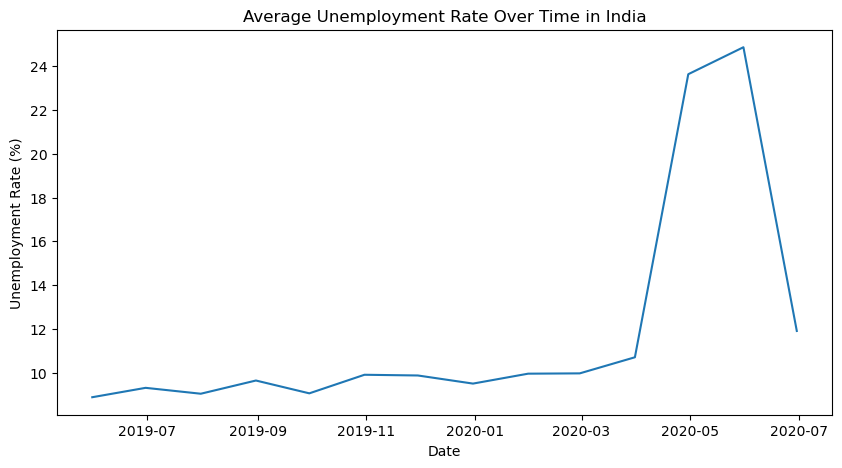

In [25]:
import matplotlib.pyplot as plt

avg_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_unemployment.index, avg_unemployment.values)
plt.title("Average Unemployment Rate Over Time in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()


This graph shows how the unemployment rate changes over time (month by month).
Each point reflects unemployment at a given time
### Conclusions derived from the graph:
- There is a sharp spike during the Covid-19 period

- Unemployment was relatively stable before Covid

- The sudden increase reflects lockdowns and economic slowdown

C:\Users\Ishani Phukan\AppData\Local\Temp\ipykernel_9612\2476115957.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


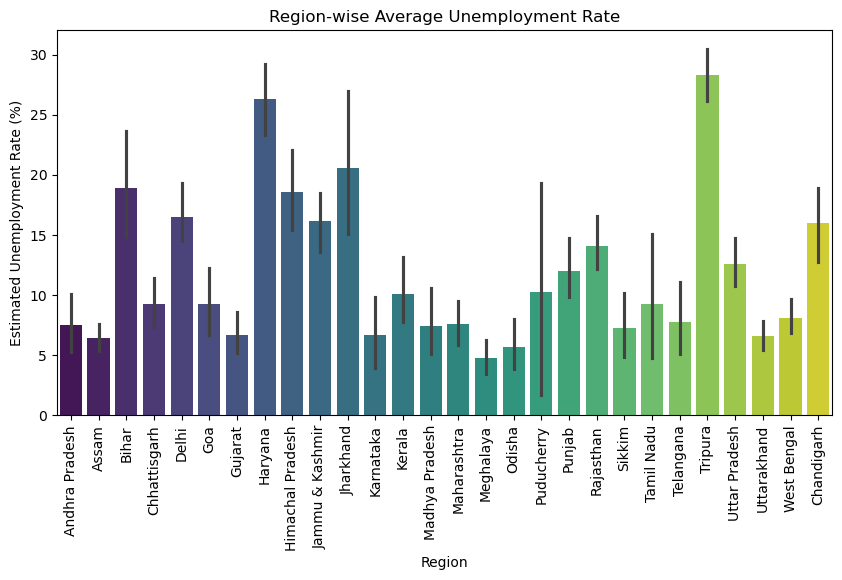

In [19]:
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    x='Region',
    y='Estimated Unemployment Rate (%)',
    data=df,
    palette='viridis'
)
plt.xticks(rotation=90)
plt.title("Region-wise Average Unemployment Rate")
plt.show()


This graph compares the average unemployment rate across different regions/states.

Each bar shows the average unemployment rate of a region

### Conclusions derived from the graph:

- Unemployment impact was not uniform

- Some regions were more affected than others

- Highlights regional economic disparity

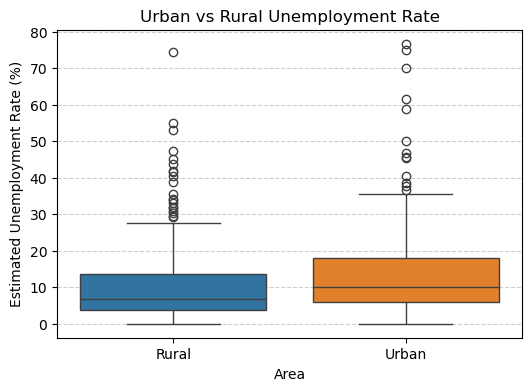

In [45]:
plt.figure(figsize=(6,4))
plt.grid(axis='y', linestyle='--', alpha=0.6)

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df,
    hue='pas',
    legend=False
)
plt.title("Urban vs Rural Unemployment Rate")
plt.show()


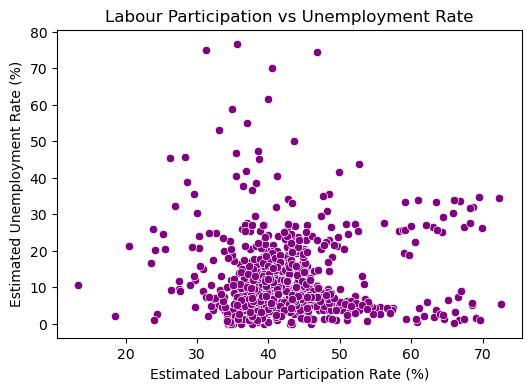

In [23]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df,
    color='purple'
)
plt.title("Labour Participation vs Unemployment Rate")
plt.show()


# Observation

In [ ]:
i) Unemployment rate increased sharply during the Covid-19 period

ii) Urban areas experienced higher and more volatile unemployment compared to rural areas

iii) Several extreme unemployment spikes were observed, indicating severe economic disruption

iv) The impact of Covid-19 on employment was uneven across regions